# Problem Statement
Build a model to predict risk of heart disease using patient health records.  

# Goal
- Load and clean the Heart Disease UCI dataset  
- Perform EDA to identify important trends  
- Train and evaluate classification models (Logistic Regression and Decision Tree)  
- Report accuracy, ROC curve, confusion matrix, and feature importance  
- Provide explanations and final insights

In [80]:
# Import libraries for analysis and modeling
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

In [81]:
# Load the Heart Disease dataset (place `heart.csv` in this folder or adjust path)
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Dataset shape
df.shape

(303, 14)

In [ ]:
# Column names
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [84]:
# Missing values per column
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [85]:
# Dataset overview and missing-value check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [86]:
# Summary statistics for the numeric heart-disease features
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


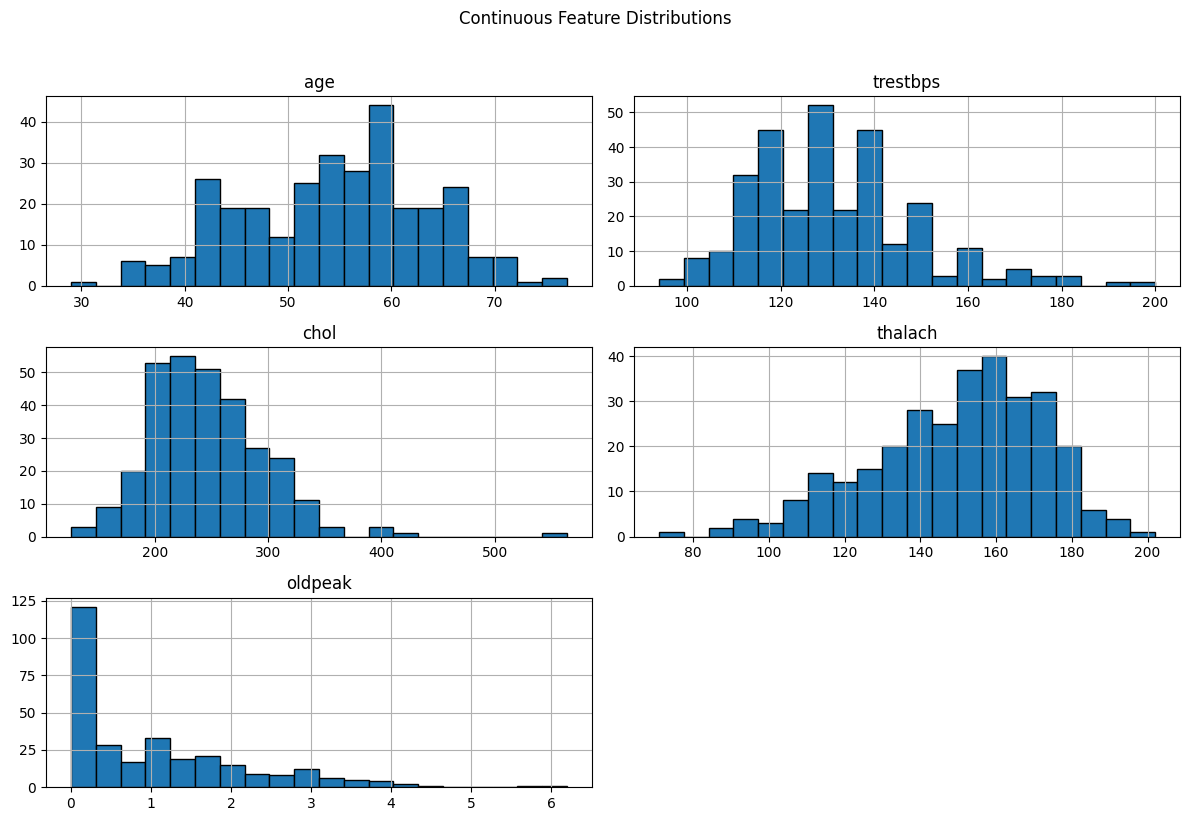

In [87]:
# Distributions of continuous features
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
df[continuous_cols].hist(bins=20, figsize=(12, 8), edgecolor='black')
plt.suptitle('Continuous Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_11456\3447979362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\Dell\AppData\Local\Temp\ipykernel_11456\3447979362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\Dell\AppData\Local\Temp\ipykernel_11456\3447979362.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
C:\Users\Dell\AppData\Local\Temp\ipykernel_11456\3447979362.py:6: FutureW

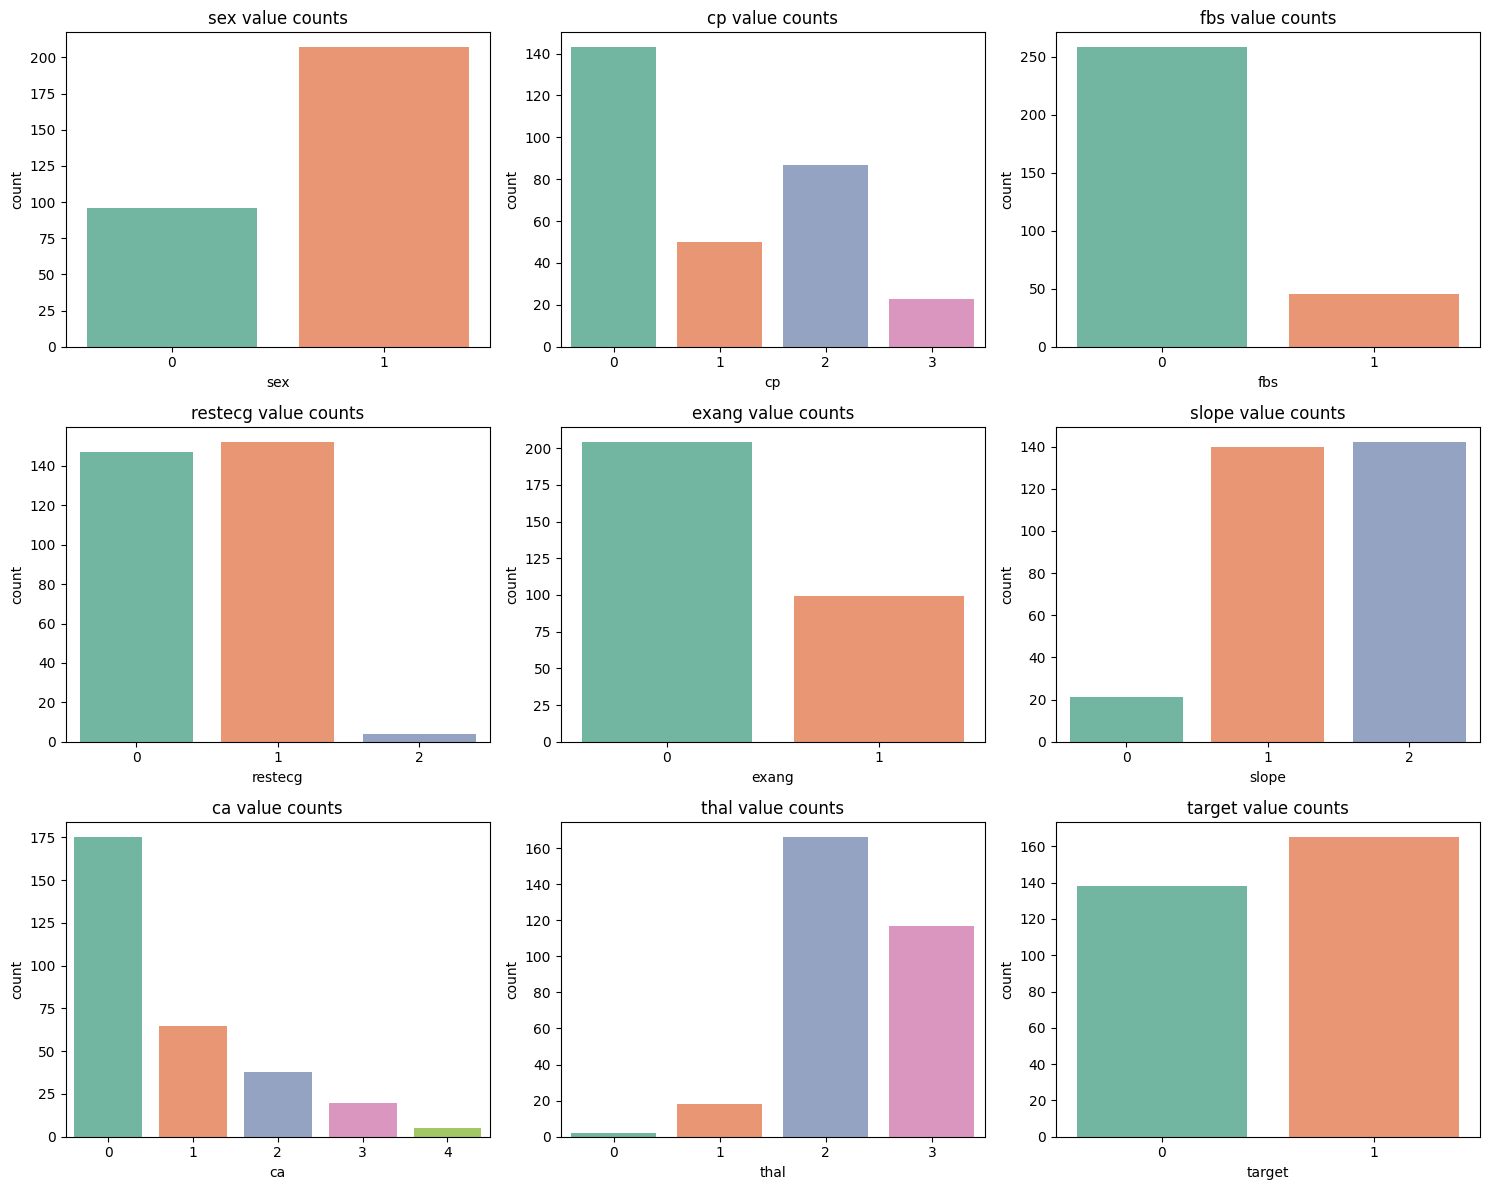

In [88]:
# Value counts for categorical-coded features and target
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} value counts')
    axes[i].tick_params(axis='x')
plt.tight_layout()
plt.show()

In [ ]:
# Count duplicate rows
df.duplicated().sum()

np.int64(1)

In [ ]:
# Remove duplicate rows in-place
df.drop_duplicates(inplace=True)

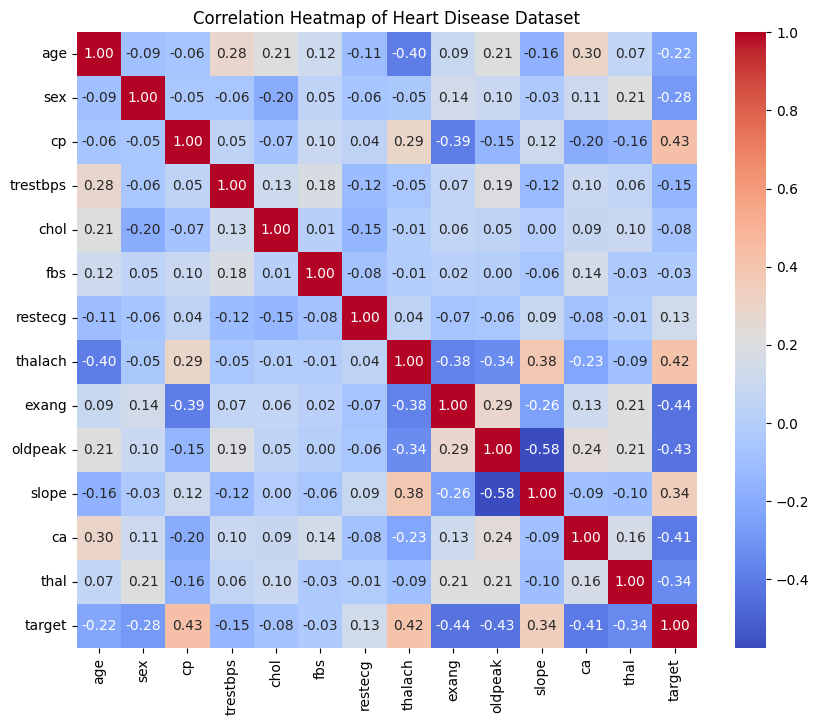

In [91]:
# heat map
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Heart Disease Dataset')
plt.show()

In [92]:
# Rank features by absolute correlation with the target
corr_with_target = df.corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)
print('Absolute correlation with target:')
print(corr_with_target)

Absolute correlation with target:
exang       0.435601
cp          0.432080
oldpeak     0.429146
thalach     0.419955
ca          0.408992
slope       0.343940
thal        0.343101
sex         0.283609
age         0.221476
trestbps    0.146269
restecg     0.134874
chol        0.081437
fbs         0.026826
Name: target, dtype: float64


In [93]:
# Keep stronger features and drop weaker ones before training
selected_features = corr_with_target[corr_with_target >= 0.10].index.tolist()
dropped_features = [col for col in df.columns if col != 'target' and col not in selected_features]

print('Selected features:', selected_features)
print('Dropped features:', dropped_features)

Selected features: ['exang', 'cp', 'oldpeak', 'thalach', 'ca', 'slope', 'thal', 'sex', 'age', 'trestbps', 'restecg']
Dropped features: ['chol', 'fbs']


In [ ]:
# Prepare feature matrix X and target y
X = df[selected_features]
y = df['target']

In [95]:
# Split the selected features into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Scale numeric features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [ ]:
# Train Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [ ]:
# Compute evaluation metrics for both models
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dt = accuracy_score(y_test, y_pred_dt)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(f'Logistic Regression:\nAccuracy: {acc_lr:.4f}\nROC AUC: {auc_lr:.4f}\nConfusion Matrix:\n{cm_lr}\n\n')
print(f'Decision Tree:\nAccuracy: {acc_dt:.4f}\nROC AUC: {auc_dt:.4f}\nConfusion Matrix:\n{cm_dt}')

Logistic Regression:
Accuracy: 0.8033
ROC AUC: 0.9015
Confusion Matrix:
[[19  9]
 [ 3 30]]


Decision Tree:
Accuracy: 0.7869
ROC AUC: 0.7684
Confusion Matrix:
[[16 12]
 [ 1 32]]


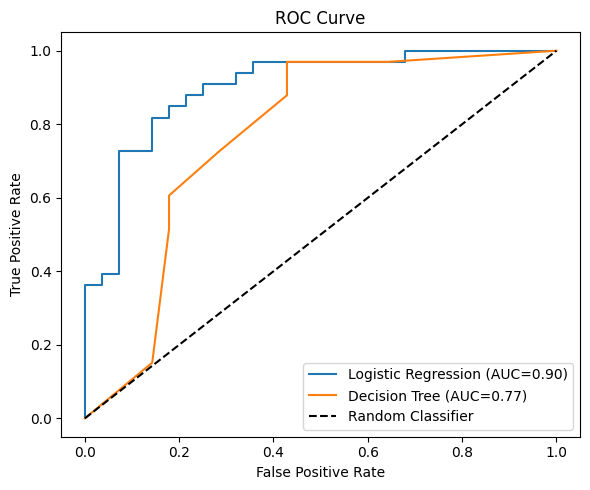

In [100]:
# Evaluate models using ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [101]:
# Highlight the most important selected features
feature_names = X.columns
lr_coef = pd.Series(lr.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)
dt_importance = pd.Series(dt.feature_importances_, index=feature_names).sort_values(ascending=False)

print('Logistic Regression coefficients (sorted by absolute value):')
print(lr_coef)

print('\nDecision Tree feature importances:')
print(dt_importance)

Logistic Regression coefficients (sorted by absolute value):
cp          0.944091
oldpeak    -0.697902
sex        -0.606129
thal       -0.564470
ca         -0.563337
thalach     0.523361
exang      -0.475278
restecg     0.337462
trestbps   -0.310523
slope       0.219984
age        -0.011274
dtype: float64

Decision Tree feature importances:
cp          0.391480
oldpeak     0.158304
thal        0.116071
ca          0.080101
age         0.065790
thalach     0.049298
trestbps    0.048696
slope       0.033806
sex         0.033371
exang       0.023082
restecg     0.000000
dtype: float64


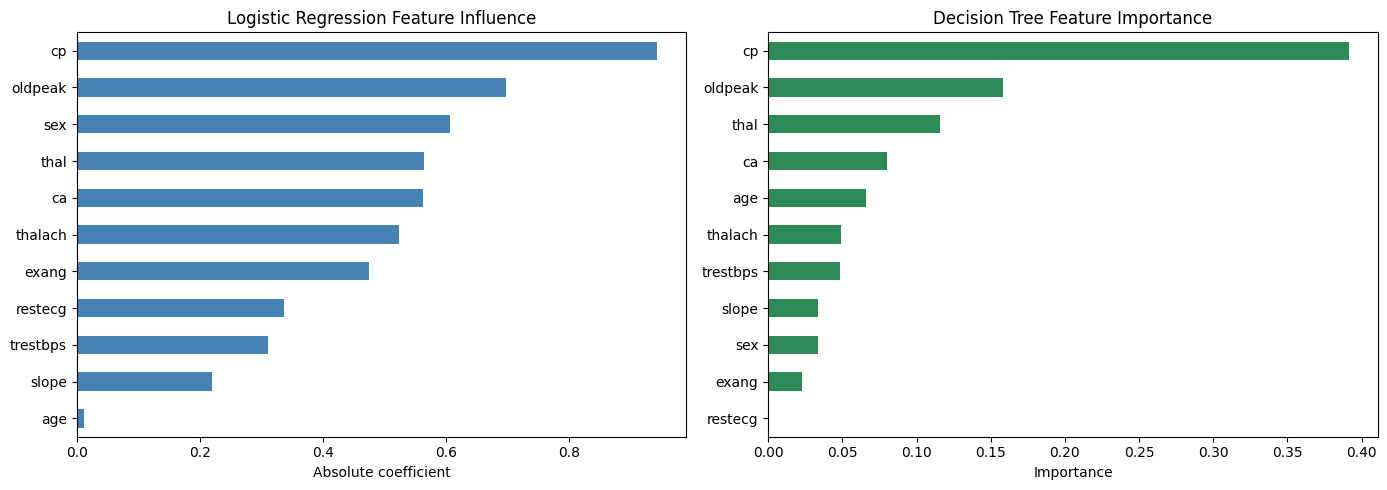

In [ ]:
# Plot logistic coefficients and tree feature importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lr_coef.abs().sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression Feature Influence')
axes[0].set_xlabel('Absolute coefficient')
dt_importance.sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title('Decision Tree Feature Importance')
axes[1].set_xlabel('Importance')
plt.tight_layout()
plt.show()

**Explanation of Results**
- The dataset was cleaned by removing duplicates.
- EDA and the correlation filter retained stronger predictors and dropped weaker features such as `chol` and `fbs`.
- On the test split, Logistic Regression achieved Accuracy = 0.8033 and ROC AUC = 0.9015, while the Decision Tree achieved Accuracy = 0.7869 and ROC AUC = 0.7684.
- The confusion matrices indicate Logistic Regression had fewer misclassifications overall and better separation for positive heart-disease cases.

**Final Insights**
- The most influential features were: `cp`, `oldpeak`, `thal`, `ca`, `thalach`, and `exang`. These contributed most strongly to predictions.
- Removing low-signal features (`chol`, `fbs`) reduced noise and improved interpretability without hurting performance.
- Logistic Regression is the stronger model on this dataset and split while Decision Tree provides interpretable decision rules and complementary insights.
- Next steps: perform cross-validation, tune hyperparameters, consider ensemble methods, and evaluate stability of the selected feature set across folds.